In [13]:
import numpy as np
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

### Convert a Multiline FASTA to a Single-line Format
This converts FASTA where sequences span multiple lines into one where each sequence is on a single line.

### Save the Reformatted Single-line FASTA
Read and write the FASTA file with headers intact.

In [14]:
def convert_fasta(infile, outfile):
    """Read a multiline FASTA and write it in single-line format."""
    with open(infile, 'r') as fin, open(outfile, 'w') as fout:
        header, seq_lines = None, []
        for line in fin:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if header:
                    fout.write(header + '\n')
                    fout.write(''.join(seq_lines) + '\n')
                header, seq_lines = line, []
            else:
                seq_lines.append(line)
        if header:
            fout.write(header + '\n')
            fout.write(''.join(seq_lines) + '\n')

in_fasta = "multiline_input.fasta"
out_fasta = "singleline_output.fasta"
convert_fasta(in_fasta, out_fasta)

# Build a Markov Transition Matrix

### Process for Markov Chain Construction:
1. Convert FASTA to single-line
2. Concatenate all sequences
3. Count dinucleotides
4. Normalize counts into probabilities

### Load the Processed FASTA and Merge Sequences
Skip header lines and build one comprehensive DNA string.

In [15]:
fasta_path = out_fasta  
all_sequences = []
with open(fasta_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith('>'):
            all_sequences.append(line)
concat_seq = ''.join(all_sequences)

### Tally Dinucleotide Occurrences
Count adjacent nucleotide pairs to prepare the transition matrix.

In [16]:
bases = ['A', 'C', 'G', 'T']
di_counts = defaultdict(lambda: defaultdict(int))
for i in range(len(concat_seq) - 1):
    b1, b2 = concat_seq[i], concat_seq[i+1]
    if b1 in bases and b2 in bases:
        di_counts[b1][b2] += 1

### Build and Normalize the Transition Matrix
Convert raw counts into probability values.

In [17]:
markov = pd.DataFrame(0.0, index=bases, columns=bases)
for b_from in bases:
    total = sum(di_counts[b_from].values())
    for b_to in bases:
        if total > 0:
            markov.loc[b_from, b_to] = di_counts[b_from][b_to] / total
markov = markov.astype(float)

### Visualize the Matrix with a Heatmap
Using seaborn for a clear graphical representation.

Transition matrix:


,A,C,G,T
A,0.250870,0.242645,0.264790,0.241696
C,0.246548,0.254438,0.244905,0.254109
G,0.251826,0.247380,0.255637,0.245157
T,0.270936,0.237438,0.250246,0.241379


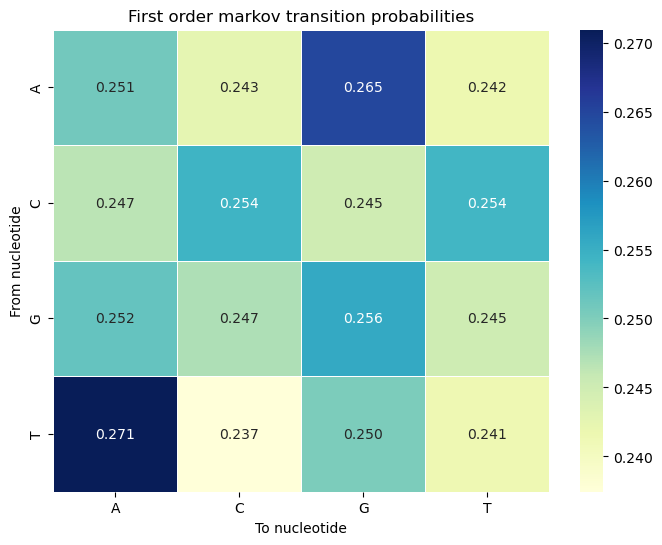

In [18]:
print("Transition matrix:")
display(markov)

plt.figure(figsize=(8,6))
sns.heatmap(markov, annot=True, cmap='YlGnBu', fmt='.3f', linewidths=0.5)
plt.title('First order markov transition probabilities')
plt.xlabel('To nucleotide')
plt.ylabel('From nucleotide')
plt.show()